# **Week 1 Notebook**
**Lundy Zheng**

For the first week of the Lendo Capital internship, I will mostly be working on some setup work. Notably, I've set up a conda environment, a GitHub repository, and organized a place where my work will be completed. In particular, I've also completed some preliminary data compilation work.

# Task 1
This is completed; check install requirements with: pip install -r requirements.txt

# Task 2

The goal of this task is to: 1. set up the function to grab datasets using yfinance; 2. load in a sample dataset and arrange it into the desired form.

In [1]:
#Download Packages
import yfinance as yf
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt

In [2]:
#49 Tickers from S&P500 and SPY (51 total)
portfolio_tickers = [
    "NVDA", "AAPL", "GOOGL", "GOOG", "MSFT", "AMZN", "META", "AVGO", "TSLA", "MU",
    "BRK-B", "LLY", "AMD", "JPM", "WMT", "V", "XOM", "INTC", "JNJ", "MA",
    "ABBV", "ORCL", "DIS", "CSCO", "CVX", "COST", "BAC", "LRCX", "KO", "AMAT",
    "MRK", "CAT", "DELL", "PG", "UNH", "GE", "MS", "PANW", "HD", "NFLX",
    "PM", "GS", "IBM", "ANET", "WFC", "CRWD", "RTX", "VZ", "TXN", "TMUS"
]

benchmark_ticker = "SPY"

tickers = portfolio_tickers + [benchmark_ticker]

start_date = "2020-01-01"
end_date = "2026-06-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False
)

data.head()

[*********************100%***********************]  51 of 51 completed


Price       Adj Close                                                         \
Ticker           AAPL       ABBV       AMAT        AMD       AMZN       ANET   
Date                                                                           
2020-01-02  72.271553  68.210747  58.563942  49.099998  94.900497  12.795000   
2020-01-03  71.568909  67.563278  57.631836  48.599998  93.748497  12.553125   
2020-01-06  72.139206  68.096466  56.388981  48.389999  95.143997  12.678750   
2020-01-07  71.799927  67.707993  58.017864  48.250000  95.343002  12.803125   
2020-01-08  72.954918  68.187881  57.980209  47.830002  94.598503  12.936250   

Price                                                     ...    Volume  \
Ticker           AVGO        BAC       BRK-B         CAT  ...       SPY   
Date                                                      ...             
2020-01-02  27.583530  30.274992  228.389999  132.067886  ...  59151200   
2020-01-03  26.881941  29.646383  226.179993  130.234192  ...  77709700   
2020-01-06  26.841732  29.603918  226.990005  130.146469  ...  55653900   
2020-01-07  26.749321  29.408531  225.919998  128.426865  ...  40496400   
2020-01-08  26.415642  29.705847  225.990005  129.567413  ...  68296000   

Price                                                                 \
Ticker         TMUS       TSLA      TXN      UNH         V        VZ   
Date                                                                   
2020-01-02  3392700  142981500  4614000  2543400   8733000  11447900   
2020-01-03  1831900  266677500  4057200  2711400   4899700  13263200   
2020-01-06  2675300  151995000  4345400  3079100  10109500  15094500   
2020-01-07  3262400  268231500  7184100  2492900   4392300  14293100   
2020-01-08  3037400  467164500  3546900  3379200   5712000  15926500   

Price                                     
Ticker           WFC       WMT       XOM  
Date                                      
2020-01-02  16803100  20294700  12456400  
2020-01-03  15608800  16197600  17386900  
2020-01-06  13200300  19336500  20081900  
2020-01-07  13278600  20540700  17387700  
2020-01-08  16585600  17627400  15137700  

[5 rows x 306 columns]

In [3]:
#Clean data to what we want it to look like
df = data.stack(level="Ticker", future_stack=True).reset_index()

df = df.rename(columns={
    "Date": "date",
    "Ticker": "ticker",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Adj Close": "adjusted_close",
    "Volume": "volume"
})

df = df[
    [
        "date",
        "ticker",
        "open",
        "high",
        "low",
        "close",
        "adjusted_close",
        "volume",
    ]
]

df.columns.name = None

df.head(5)

,date,ticker,open,high,low,close,adjusted_close,volume
0,2020-01-02,AAPL,74.059998,75.150002,73.797501,75.087502,72.271553,135480400
1,2020-01-02,ABBV,89.080002,89.570000,88.510002,89.550003,68.210747,5639200
2,2020-01-02,AMAT,62.000000,62.650002,61.700001,62.200001,58.563942,6647900
3,2020-01-02,AMD,46.860001,49.250000,46.630001,49.099998,49.099998,80331100
4,2020-01-02,AMZN,93.750000,94.900497,93.207497,94.900497,94.900497,80580000


In [4]:
#Now that the dataset is arranged properly, we will download it and be able to pull it with the load_ohlcv() function.
df.to_csv(
    "../data/processed/ohlcv.csv",
    index=False
)

#GPT recommended this file format rather than the usual csv. I'll go with this for now.
df.to_parquet(
    "../data/processed/ohlcv.parquet",
    index=False
)

def load_ohlcv(path):
    """
    This function reads a .parquet file into a the notebook as a dataset (df).
    
    Input:
        path: file path on computer
        
    Output:
        dataframe: containing stock data
    """
    
    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values(
        ["ticker", "date"]
    ).reset_index(drop=True)

    return df

# Task 3

Next, we conduct a data quality check of the dataset processed in Task 2. Checking notably for:
1. Missing data - if = NaN
2. Duplicate rows/dates - if more than two of the same date appears, for the same ticker
3. Invalid dates - cannot have things like 4/31, for example.
4. Impossible values - price =< 0 or volume <0 is strange
5. Outliers - something extreme? (check values)

In [5]:
#Interlude to task 4: let's compute simple returns here so we can check extreme returns alongside the other checks.
df["daily_simple_return"] = (
    df.groupby("ticker")["adjusted_close"]
      .pct_change(fill_method = None)
)

In [6]:
#Define a bunch of subfunctions we can place in validate_ohlcv

def check_missing_data(df):
    """
    Check if any data is missing.

    Input:
        df: dataframe
        
    Output:
        dataframe of rows with missing values
    """

    missing = df.isna().sum()

    print("\nMissing values by column:")
    print(missing)

    problem_rows = df[df.isna().any(axis=1)]

    print("\nRows containing missing values: " + str(len(problem_rows)))
    print(problem_rows)

    return problem_rows
    
def check_duplicates(df):
    """
    Check if any duplicate rows exist.
    Note: This counts the number of rows that have a duplicate at all! so 2 rows of the same date --> 2 duplicate rows; 3 rows of the same date --> 3 duplicate rows

    Input:
        df: dataframe
        
    Output:
        dataframe of duplicate rows
    """

    duplicates = df[
        df.duplicated(
            subset=["ticker", "date"],
            keep=False
        )
    ]

    print("\nNumber of duplicate rows:")
    print(len(duplicates))

    print("\nDuplicate observations:")
    print(duplicates)

    return duplicates

def check_invalid_values(df):
    """
    Here we want to check if prices are invalid - notably, we will make sure that all prices >0, and volume =>0.
    We also must check that high is indeed high, and low is indeed low.

    Input:
        df: dataframe
        
    Output:
        dataframe of rows with invalid prices
    """

    price_cols = [
        "open",
        "high",
        "low",
        "close",
        "adjusted_close"
    ]
    
    invalid = df[
        (df[price_cols] <= 0).any(axis=1)
        |
        (df["volume"] < 0)
        |
        (df["high"] < df["open"])
        |
        (df["high"] < df["close"])
        |
        (df["high"] < df["low"])
        |
        (df["low"] > df["open"])
        |
        (df["low"] > df["close"])
    ]

    print("\nRows with invalid prices:")
    print(invalid)

    return invalid

def check_valid_date(df, benchmark = "SPY"):
    """
    This function checks that all the dates listed for each stock are actual days when trades are possible.
    I will use SPY as the benchmark (suggested by most online sources; plus, its S&P500) to see if other stocks dates match. But this is just the default and can be changed.

    Input:
        df: dataframe
        benchmark: ticker (str)
        
    Output:
        dataframe of rows with erroneous dates
    """

    benchmark_dates = set(
        df[df["ticker"] == benchmark]["date"]
    )

    tickers = df["ticker"].unique()

    problems = {}

    for ticker in tickers:

        ticker_dates = set(
            df[df["ticker"] == ticker]["date"]
        )

        missing_dates = benchmark_dates - ticker_dates
        extra_dates = ticker_dates - benchmark_dates

        if missing_dates or extra_dates:
            problems[ticker] = {
                "missing_dates": missing_dates,
                "extra_dates": extra_dates
            }

    print("\nCalendar discrepancies:")
    if problems == {}:
        print("No discrepancies!")
    else:
        print(problems)

    return problems

def check_extreme_returns(df, threshold = 0.25):
    """
    This function checks for whether or not the simply daily return for any ticker at any moment is suspiciously high or low.

    Input:
        df: dataframe
        threshold: what counts as extreme (fl)
        
    Output:
        dataframe of list of days with suspicious returns, for investigation.
    """
    extreme_returns = df[
        df["daily_simple_return"].abs() > threshold
    ]

    print("\nExtreme daily returns:")
    print(
        extreme_returns[
            ["date", "ticker", "adjusted_close", "daily_simple_return"]
        ]
    )

    return extreme_returns

In [28]:
def validate_ohlcv(df):
    """
    This function provides a series of checks for whether or not the data is clean & devoid of errors.

    Input:
        df: dataframe
        
    Output:
        relevant info on dataset, warnings for particular instances of values
    """

    #1. Overview: Check the big-scale information about the dataset, including duplicates
    # shape
    print("Shape")
    print(df.shape)
    
    # Overview: Column types
    print("\nColumn Types")
    print(df.dtypes)

    # basic numerical summary: hidden right now to save space
    #print("\nSummary")
    #print(df.describe())

    # missing values in each column
    missing_rows = check_missing_data(df)
    
    # duplicate ticker-date observations
    duplicates = check_duplicates(df)

    # checking if values are valid
    invalid_values = check_invalid_values(df)

    # checking if dates are valid & complete
    check_valid_date(df)

    # check if any daily simple return is suspiciously high
    check_extreme_returns(df)
    
validate_ohlcv(df)

Shape
(82110, 10)

Column Types
date                   datetime64[ns]
ticker                         object
open                          float64
high                          float64
low                           float64
close                         float64
adjusted_close                float64
volume                          int64
daily_simple_return           float64
daily_log_return              float64
dtype: object

Missing values by column:
date                    0
ticker                  0
open                    0
high                    0
low                     0
close                   0
adjusted_close          0
volume                  0
daily_simple_return    51
daily_log_return       51
dtype: int64

Rows containing missing values: 51
            date ticker        open        high         low       close  \
0     2020-01-02   AAPL   74.059998   75.150002   73.797501   75.087502   
1610  2020-01-02   ABBV   89.080002   89.570000   88.510002   89.550003   
3220  2020-01

# Task 4

Here we create a basic function that computes returns. Simple vs log returns are distinguished. Daily, weekly, monthly, and annual returns.
Simple returns over multiple days are compounded. computereturns() function, also in data_utils.py
For a check, we already computed daily simple return above. The rest below are:

1. Weekly simple return (compounded)
2. Monthly simple return (compounded)
3. Daily log return
4. Weekly log return
5. Monthly log return

Product: a compute_returns() function. I envision this function to 1. add daily return (2 types) columns to the existing dataframe, 2. create a new dataframe(s) consisting of date, ticker, and each of daily, weekly, monthly, and annual returns, 3. return distribution plots.

In [8]:
def compute_period_returns(df, frequency = "W-FRI"):
    """
    This is a subfunction for compute_returns that computes a certain frequency of returns based on input.

    Input:
        df: dataframe
        frequency: timeframe from ["W-FRI", "ME", "YE"] (str)
        
    Output:
        dataframe cropped per period, with returns computed
    """
   
    period_prices = (
    df.set_index("date")
      .groupby("ticker")[["close", "adjusted_close"]]
      .resample(frequency)
      .last()
      .dropna()
      .reset_index()
    )

    # Instead of compounding by day, AI suggested I compute simple returns through jumping from weekly endpoint to weekly endpoint. I also coded a simple test for if I used the compounding method and they do produce the same results (as we would intuitively expect)
    
    period_prices["simple_return"] = (
    period_prices.groupby("ticker")["adjusted_close"]
                 .pct_change(fill_method=None)
    )

    period_prices["log_return"] = (
    np.log(period_prices["adjusted_close"])
    - np.log(
        period_prices.groupby("ticker")["adjusted_close"].shift(1)
    )
    )

    return period_prices

def compute_returns(df):
    """
    This function computes the daily simple & log returns of each stock, putting them as new columns in a dataframe copy.
    Simple returns are the most intuitive as they calculate percent change in closing price from the previous day. These are generally used in discussion for clarity and ease of understanding.
    Log returns take the log-difference of the closing prices, which is less convenient to think about but is very useful in summing returns, as this metric has an sums well (whereas simple returns require a compound formula).

    Input:
        df: dataframe
        
    Output:
        dataframe with extra columns on daily returns, dataframe with all types of returns
    """

    df = df.copy()

    # Make sure observations are ordered correctly
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    # Daily simple return --> already done in this notebook but included here for future ones.
    df["daily_simple_return"] = (
        df.groupby("ticker")["adjusted_close"]
          .pct_change(fill_method=None)
    )

    # Daily log return
    df["daily_log_return"] = (
        np.log(df["adjusted_close"])
        - np.log(
            df.groupby("ticker")["adjusted_close"].shift(1)
        )
    )

    daily = df[
        [
            "date",
            "ticker",
            "close",
            "adjusted_close",
            "daily_simple_return",
            "daily_log_return"
        ]
    ].copy()
    
    daily = daily.rename(
        columns={
            "daily_simple_return": "simple_return",
            "daily_log_return": "log_return"
        }
    )

    daily["frequency"] = "daily"
    
    # Weekly
    weekly = compute_period_returns(df, "W-FRI")
    weekly["frequency"] = "weekly"

    # Monthly
    monthly = compute_period_returns(df, "ME")
    monthly["frequency"] = "monthly"

    # Annual (not required)
    annual = compute_period_returns(df, "YE")
    annual["frequency"] = "annual"

    # Check columns are consistent
    columns = [
        "date",
        "ticker",
        "close",
        "adjusted_close",
        "simple_return",
        "log_return",
        "frequency"
    ]
    
    daily = daily[columns]
    weekly = weekly[columns]
    monthly = monthly[columns]
    annual = annual[columns]

    # Combine all these calculated values into one dataframe,
    returns_df = pd.concat(
        [daily, weekly, monthly, annual],
        ignore_index=True
    )

    return df, returns_df

df, returns_df = compute_returns(df)
returns_df.head()

,date,ticker,close,adjusted_close,simple_return,log_return,frequency
0,2020-01-02,AAPL,75.087502,72.271553,NaN,NaN,daily
1,2020-01-03,AAPL,74.357498,71.568909,-0.009722,-0.009770,daily
2,2020-01-06,AAPL,74.949997,72.139206,0.007969,0.007937,daily
3,2020-01-07,AAPL,74.597504,71.799927,-0.004703,-0.004714,daily
4,2020-01-08,AAPL,75.797501,72.954918,0.016086,0.015958,daily


In [9]:
# I find the returns_df dataframe rather annoying to read so I separated them here again for clarity:
daily_returns = returns_df[
    returns_df["frequency"] == "daily"
].drop(columns="frequency").reset_index(drop=True).copy()

weekly_returns = returns_df[
    returns_df["frequency"] == "weekly"
].drop(columns="frequency").reset_index(drop=True).copy()

monthly_returns = returns_df[
    returns_df["frequency"] == "monthly"
].drop(columns="frequency").reset_index(drop=True).copy()

annual_returns = returns_df[ #This is extra.
    returns_df["frequency"] == "annual"
].drop(columns="frequency").reset_index(drop=True).copy()

#print("Daily")
#display(daily_returns.head())

#print("Weekly")
#display(weekly_returns.head())

#print("Monthly")
#display(monthly_returns.head())

#print("Annual")
#display(annual_returns.head(10))

In [10]:
# The final goal of this task is to create return distribution plots. Do the most basic histogram (and I can try to improve from here)

def plot_return_distribution(
    returns_df,
    frequency,
    return_type="simple_return",
    bins=50,
    tickers=None
):
    """
    Plot the distribution of returns for a given frequency and return type.

    Input:
        returns_df: dataframe
        frequency: how often the data was sampled, from ["daily", "weekly", "monthly", "annual"] (str)
        return_type: "simple_return" or "log_return" (str)
        bins: bin size (int)
        tickers: optional, list of tickers to track in specific (list or str)
           
    Output:
        plot
    """

    data = returns_df[
        returns_df["frequency"] == frequency
    ].copy()

    # Filter by ticker(s) only when specified in argument (for selecting a few companies or a benchmark)
    if tickers is not None:
        if isinstance(tickers, str):
            tickers = [tickers]

        data = data[
            data["ticker"].isin(tickers)
        ]
    if tickers is None:
        ticker_title = "All Stocks"
    else:
        ticker_title = ", ".join(tickers)

    data = data[return_type].dropna()
    
    # So the range on the plot isn't very big
    lower = data.quantile(0.01)
    upper = data.quantile(0.99)

    plt.figure(figsize=(8, 5))

    plt.axvline(
        0,
        linestyle="--",
        color="black",
        label="Zero Return"
    )
    
    average_return = data.mean()

    plt.axvline(
        average_return,
        linestyle="--",
        color="red",
        label=f"Average Return ({average_return:.4f})"
    )

    plt.hist(
        data,
        bins=bins,
        range=(lower, upper)
    )

    plt.title(
        f"{ticker_title} - {frequency.capitalize()} "
        f"{return_type.replace('_', ' ').title()} Distribution"
    )

    plt.xlabel("Return")
    plt.ylabel("Frequency")

    #Add some extra features

    plt.legend()

    plt.show()

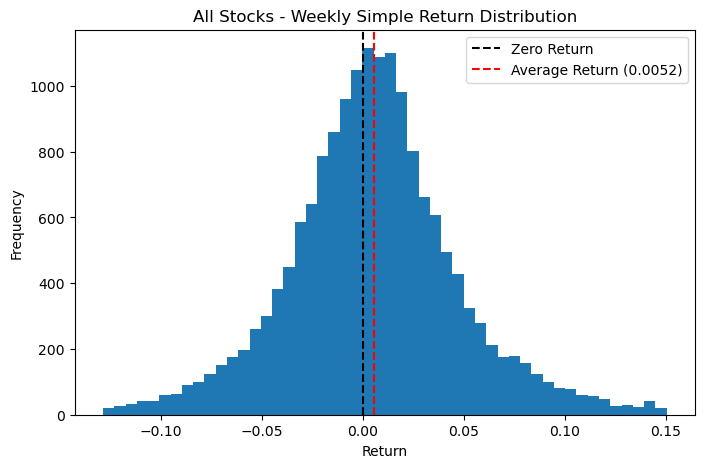

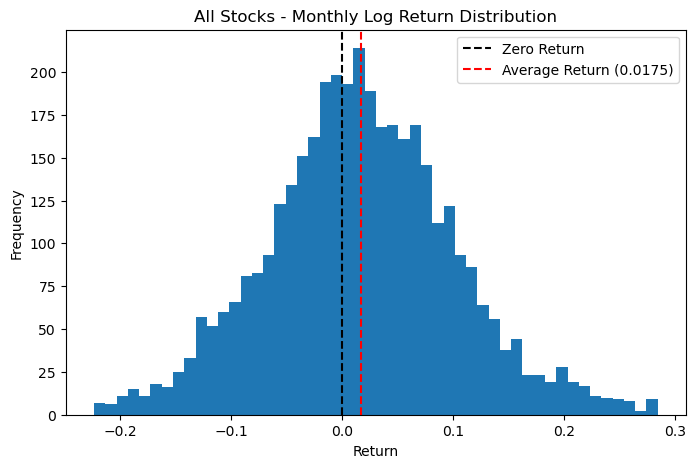

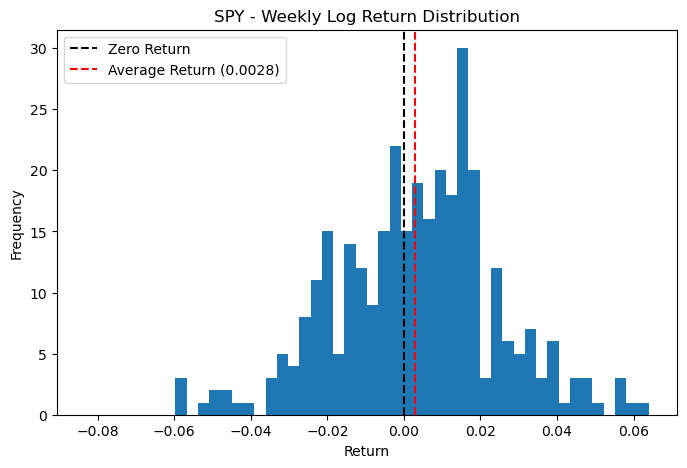

In [11]:
plot_return_distribution(returns_df, "weekly", "simple_return")
plot_return_distribution(returns_df, "monthly", "log_return")
plot_return_distribution(returns_df, "weekly", "log_return", tickers=["SPY"])

# Task 5

For the final task this week, we add rolling statistics to our data. Specifically, we first compute several key quantities to measure data shape/spread such as mean, volatility, skewness, kurtosis.
We also compute annualized returns, annualized volatility, sharpe ratio, and max drawdown.
Next we build equal-weight and value-weight sample portfolios.

In [12]:
# For the first part, I'm going to start from the daily_returns / weekly_returns dataframes and compute rolling statistics given a number of days (as an input)]

def rolling_statistics(
    returns_df,
    window=20,
    return_type="simple_return"
):
    """
    This function computes the relevant rolling statistics for the returns dataframe, given the rolling window.

    Input:
        returns_df: dataframe (returns)
        window: sample window (int)
        return_type: "simple_return" or "log_return" (str)
        
    Output:
        dataframe (returns) with added columns on rolling mean, volatility, skewness, kurtosis
    """

    if return_type == "simple_return":
        heading = "_simple"
    if return_type == "log_return":
        heading = "_log"
    
    df = returns_df.copy()
    df = df.sort_values(["ticker", "date"])
    grouped = df.groupby("ticker")[return_type]

    # Mean
    df["rolling_mean"+heading] = grouped.transform(
        lambda x: x.rolling(window).mean()
    )

    # Volatility (stddev)
    df["rolling_volatility"+heading] = grouped.transform(
        lambda x: x.rolling(window).std()
    )

    # Skewness
    df["rolling_skewness"+heading] = grouped.transform(
        lambda x: x.rolling(window).skew()
    )

    # Kurtosis
    df["rolling_kurtosis"+heading] = grouped.transform(
        lambda x: x.rolling(window).kurt()
    )

    return df

In [13]:
monthly_returns = rolling_statistics(monthly_returns, return_type = "log_return")
monthly_returns = rolling_statistics(monthly_returns, return_type = "simple_return")

weekly_returns = rolling_statistics(weekly_returns, return_type = "log_return")
weekly_returns = rolling_statistics(weekly_returns, return_type = "simple_return")

daily_returns = rolling_statistics(daily_returns, return_type= "log_return")
daily_returns = rolling_statistics(daily_returns, return_type= "simple_return")

In [14]:
# The next appropriate step is to create equal-weight & value-weight portfolios.
# The premise is essentially to track our cumulative returns (& other statistics) given we invest in these 50 stocks.
# The equal-weight case is just a simple mean (since we don't need to consider weights).
# Each day we combine all our stock's returns

def build_equal_weight_portfolio(
    returns_df,
    return_type="simple_return",
    benchmark_ticker="SPY"
):
    """
    Simple function that calculates the returns of an equal-weight portfolio

    Input:
        returns_df: dataframe (returns_df type document, such as "weekly_returns")
        return_type: "simple_return" or "log_return" (str)
        benchmark_ticker: "SPY" (str)
        
    Output:
        dataframe (new dataframe, of equal-weight returns each date
    """

    portfolio_df = returns_df[
        returns_df["ticker"] != benchmark_ticker
    ].copy()
    
    portfolio = (
        returns_df
        .groupby("date")[return_type]
        .mean()
        .reset_index()
    )

    portfolio = portfolio.rename(
        columns={return_type: "ew_portfolio_return"}
    )

    return portfolio

ew_log_weekly_portfolio = build_equal_weight_portfolio(weekly_returns, return_type="log_return")
ew_log_daily_portfolio = build_equal_weight_portfolio(daily_returns, return_type="log_return")

ew_simple_daily_portfolio = build_equal_weight_portfolio(daily_returns, return_type="simple_return")
ew_simple_weekly_portfolio = build_equal_weight_portfolio(weekly_returns, return_type="simple_return")

In [15]:
# Here I try to make a value-weight portfolio. Because this task seemed the most difficult, I left this to be done after I did everything else.
# I'm aware that you can grab current market cap right now and weigh stocks like that, but I wonder if there's some-sort of "seeing into the future" going on in a practical standpoint, and we should evaluate based on market cap at start date.
# We'll have to define a few functions to grab the shares outstanding data.
def get_shares_outstanding(ticker, start_date=start_date):
    """
    This function pulls historical shares outstanding for a given ticker.

    Input:
        ticker: the name of the ticker, e.g., "AAPL" (str)

    Output:
        dataframe with ticker, date, and shares_outstanding
    """
    stock = yf.Ticker(ticker)

    shares = stock.get_shares_full(
        start=start_date
    )

    if shares is None:
        print(f"No shares outstanding data found for {ticker}")
        return None

    shares_df = shares.reset_index()

    shares_df.columns = [
        "date",
        "shares_outstanding"
    ]

    shares_df["ticker"] = ticker

    return shares_df

def get_all_shares_outstanding(tickers):
    """
    Once we have the individual shares outstanding data for each company, we need to combine these into one dataframe.

    Input:
        tickers: exhaustive list of tickers

    Output:
        dataframe complete with date, tickers and shares outstanding                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    o        ooooooooooodoooooodoododooooodooododooooddooodooooooodoooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooojij
    """

    shares_list = []

    # Combine into one big dataframe using above function
    for ticker in tickers:
        shares_df = get_shares_outstanding(ticker)
        shares_list.append(shares_df)

    all_shares_df = pd.concat(
        shares_list,
        ignore_index=True
    )

    all_shares_df = all_shares_df.sort_values(
        ["ticker", "date"]
    ).reset_index(drop=True)

    return all_shares_df
    
shares_df = get_all_shares_outstanding(portfolio_tickers)

def merge_shares_with_returns(
    returns_df,
    shares_df,
    benchmark_ticker="SPY"
):
    """
    Merge historical shares outstanding data into the returns_df dataframe for calculating value-weight portfolio.
    The benchmark ticker is excluded from the portfolio.
    For each stock/date, the most recent available shares outstanding
    observation is used.

    Input:
        returns_df: dataframe of returns, with close price. Should be "daily_returns", "weekly_returns", etc.
                    Do not use the entire returns_df.
        shares_df: dataframe of shares outstanding for each stock
        benchmark_ticker: "SPY"

    Output:
        dataframe, merged
    """
    
    portfolio_df = returns_df[
        returns_df["ticker"] != benchmark_ticker
    ].copy()

    shares_df = shares_df.copy()

    # Check timezones/ date convention is consistent
    shares_df["date"] = (
        pd.to_datetime(shares_df["date"])
          .dt.tz_localize(None)
    )

    portfolio_df["date"] = pd.to_datetime(portfolio_df["date"])

    # Make sure dates are datetime
    portfolio_df["date"] = pd.to_datetime(portfolio_df["date"])
    shares_df["date"] = pd.to_datetime(shares_df["date"])

    # Required for merge_asof
    portfolio_df = portfolio_df.sort_values(
        ["date", "ticker"]
    ).reset_index(drop=True)

    shares_df = shares_df.sort_values(
        ["date", "ticker"]
    ).reset_index(drop=True)

    combined_df = pd.merge_asof(
        portfolio_df,
        shares_df,
        on="date",
        by="ticker",
        direction="backward"
    )

    return combined_df

daily_combined_df = merge_shares_with_returns(daily_returns, shares_df)
weekly_combined_df = merge_shares_with_returns(weekly_returns, shares_df)
monthly_combined_df = merge_shares_with_returns(monthly_returns, shares_df)



In [16]:
# Now we can finally build our function for the value-weight portfolio
def build_value_weight_portfolio(
    combined_df,
    return_column="simple_return",
    benchmark_ticker="SPY"
):
    """
    Function that calculates the value-weight portfolio.
    Value-weights are selected by calculating the most-recently known market cap (fromshares outstanding & close) at that time.

    Inputs:
        combined_df: dataframe with relevant columns from previous functions. Shouldn't come from the whole returns_df
        return_type: column of return - "simple_return" or "log_return" (str)
        benchmark_ticker="SPY"
    """

    df = combined_df.copy()

    # Calculate market capitalization
    df["market_cap"] = (
        df["close"] * df["shares_outstanding"]
    )

    # Calculate each stock's weight within each date
    df["value_weight"] = (
        df["market_cap"]
        / df.groupby(
            ["date"]
        )["market_cap"].transform("sum")
    )

    # Use the previous period's weight
    df["portfolio_weight"] = (
        df.groupby(
            ["ticker"]
        )["value_weight"].shift(1)
    )

    # Calculate each stock's contribution to portfolio return
    df["weighted_return"] = (
        df["portfolio_weight"] * df[return_column]
    )

    # Sum contributions to get portfolio return
    val_portfolio_returns = (
        df.groupby(
            ["date"]
        )["weighted_return"]
        .sum()
        .reset_index(name="val_portfolio_return")
    )

    return df, val_portfolio_returns    

val_simple_daily_portfolio = build_value_weight_portfolio(daily_combined_df, "simple_return")[1]
val_simple_weekly_portfolio = build_value_weight_portfolio(weekly_combined_df, "simple_return")[1]

In [17]:
# Next in this task, for annualized returns, annualized volatility, sharpe ratio, and max drawdown.
# Note 252 trading days in a year. And the annualized returns here is regarding the whole portfolio performance, rather than

def portfolio_performance(
    portfolio,
    frequency="daily",
    return_type="simple_return",
    return_column="ew_portfolio_return",
    risk_free_rate=0
):
    """
    Compute portfolio performance statistics.

    Input:
        portfolio: dataframe containing portfolio returns (e.g., ew_daily_portfolio)
        frequency: "daily", "weekly", "monthly", or "annual"
        return_type: "simple_return" or "log_return"
        return_column: name of returns column, e.g. "ew_portfolio_return" or "val_portfolio_return"
        risk_free_rate: annual risk-free rate

    Output:
        annualized return, annualized volatility, Sharpe ratio, and maximum drawdown
    """
        
    returns = portfolio[return_column].dropna()

    # Because we might want to insert different portfolios samples (sampled daily vs weekly, for example), we need to calculate total periods per year for subsequent calcs.
    periods = {
        "daily": 252,
        "weekly": 52,
        "monthly": 12,
        "annual": 1
    }

    periods_per_year = periods[frequency]

    if return_type == "simple_return":

        # Annualized return, summing up portfolio performance (avg per year) over the entire timeframe
        # Compounded if simple
        annualized_return = (
            (1 + returns).prod()
            ** (periods_per_year / len(returns))
            - 1
        )

        # Cumulative wealth
        cumulative = (1 + returns).cumprod()

    elif return_type == "log_return":

        # Log returns are easier since we just add the returns and then take the exp to get rid of the log
        annualized_return = (
            np.exp(returns.mean() * periods_per_year)
            - 1
        )

        # Cumulative wealth
        cumulative = np.exp(returns.cumsum())

    # Annualized volatility: a standard deviation measurement = stddev_daily * sqrt(timeframe)
    annualized_volatility = (
        returns.std() * np.sqrt(periods_per_year)
    )

    # Sharpe ratio: measures performance of an investment relative to a risk-free asset, after adjusting for risk.
    sharpe_ratio = (
        (annualized_return - risk_free_rate) # Essentially return difference in comparison to what you could've gotten with investing into something without risk
        / annualized_volatility # Accounting for volatility so more risky investments --> poorer Sharpe ratio
    )

    # Maximum drawdown: largest peak to trough loss in %
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown
    }

print("Equal-Weight Portfolio Performance")
display(portfolio_performance(ew_simple_daily_portfolio, frequency="daily", return_type="simple_return", return_column="ew_portfolio_return", risk_free_rate=0.03))

print("Value-Weight Portfolio Performance")
display(portfolio_performance(val_simple_daily_portfolio, frequency="daily", return_type="simple_return", return_column="val_portfolio_return", risk_free_rate=0.03))


Equal-Weight Portfolio Performance


{'annualized_return': np.float64(0.2865422162844906),
 'annualized_volatility': np.float64(0.21569628357609652),
 'sharpe_ratio': np.float64(1.1893678093622964),
 'max_drawdown': -0.3257205276269558}

Value-Weight Portfolio Performance


{'annualized_return': np.float64(0.20224732854673944),
 'annualized_volatility': np.float64(0.22241344164340537),
 'sharpe_ratio': np.float64(0.7744465769425165),
 'max_drawdown': -0.326316412083571}

In [26]:
# The final subtask here is to plot the cumulative returns & rolling volatility.
# So I plot returns over time, as well as how volatility in the last x days varies as we go on.
# I'm creating two new functions, just like the previous plots, to do this:

def plot_cumulative_returns(
    portfolio,
    return_type="simple_return",
    return_column="ew_portfolio_return",
    frequency="daily"
):
    """
    This function generates a plot of cumulative portfolio returns.

    Input:
        portfolio: dataframe containing date and portfolio returns, e.g., ew_simple_daily_portfolio
        return_type: "simple_return" or "log_return" (str)
        return_column: name of the column containing returns, e.g., "ew_portfolio_return" (str)
        frequency: "daily", "weekly", etc. Just for the axis label (str)

    Output:
        plot of cumulative returns
    """

    df = portfolio.copy()
    returns = df[return_column].fillna(0)

    if return_type == "simple_return":
        df["cumulative_return"] = (
            (1 + returns).cumprod() - 1
        )

    elif return_type == "log_return":
        df["cumulative_return"] = (
            np.exp(returns.cumsum()) - 1
        )

    plt.figure(figsize=(10, 5))

    plt.plot(
        df["date"],
        df["cumulative_return"]
    )

    plt.axhline(
        0,
        linestyle="--",
        color="k",
        label="0% Return"
    )

    plt.title(f"'{return_column}' Portfolio Cumulative Return")
    plt.xlabel(f"Date (sampled {frequency})")
    plt.ylabel("Cumulative Return") # Units in decimal, or %/100. So 1.0 means +100% in returns

    plt.legend()
    plt.show()

def plot_rolling_volatility(
    portfolio,
    frequency="daily",
    return_column="ew_portfolio_return",
    window=20
):
    """
    This function plots annualized rolling portfolio volatility.
    I found this not too intuitive, but we are indeed calculating an annualized volatility using a sample window.
    We essentially determine a value for volatility expressed on an annual scale (sqrt(252)) given the behavior of the portfolio in the sample window

    Input:
        portfolio: dataframe containing date and portfolio returns
        frequency: "daily", "weekly", "monthly", or "annual" (str)
        return_column: name of the column containing returns, e.g., "ew_portfolio_return" (str)
        window: number of periods in rolling window (int)

    Output:
        plot of annualized rolling volatility
    """

    df = portfolio.copy()
    returns = df[return_column]

    periods = {
        "daily": 252,
        "weekly": 52,
        "monthly": 12,
        "annual": 1
    }

    periods_per_year = periods[frequency]

    df["rolling_volatility"] = (
        returns
        .rolling(window)
        .std()
        * np.sqrt(periods_per_year)
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        df["date"],
        df["rolling_volatility"]
    )

    plt.title(
        f"{window}-Period, Rolling Annualized Volatility"
    )

    plt.xlabel(f"Date (sampled {frequency})")
    plt.ylabel("Annualized Volatility") # Units also in decimal, think normalized standard deviation. So 0.30 = 30% annualized volatility.

    plt.show()
    

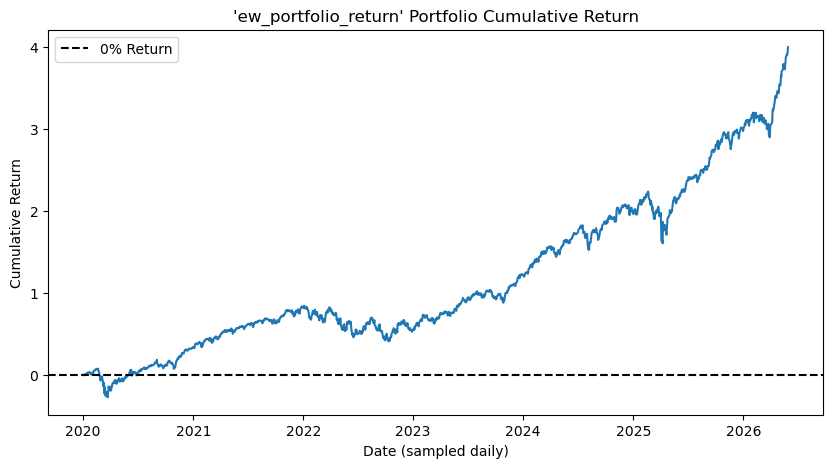

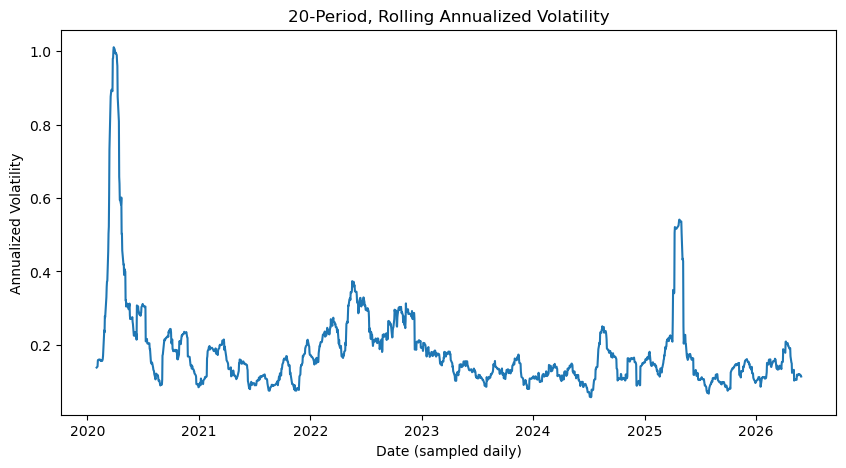

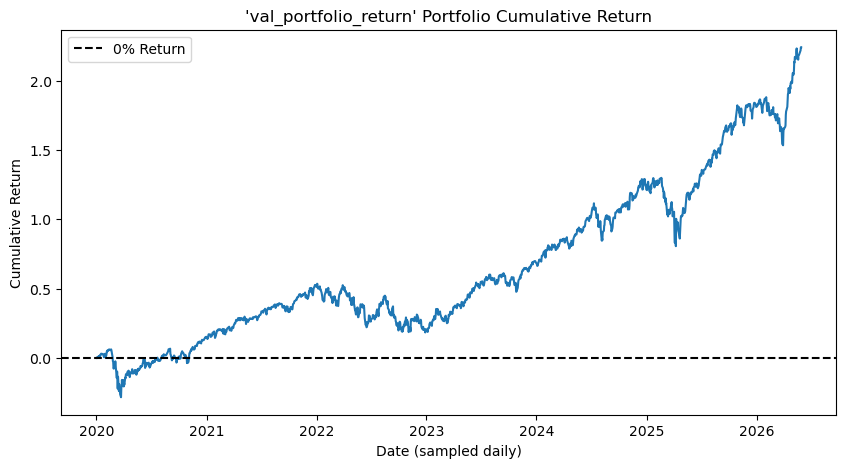

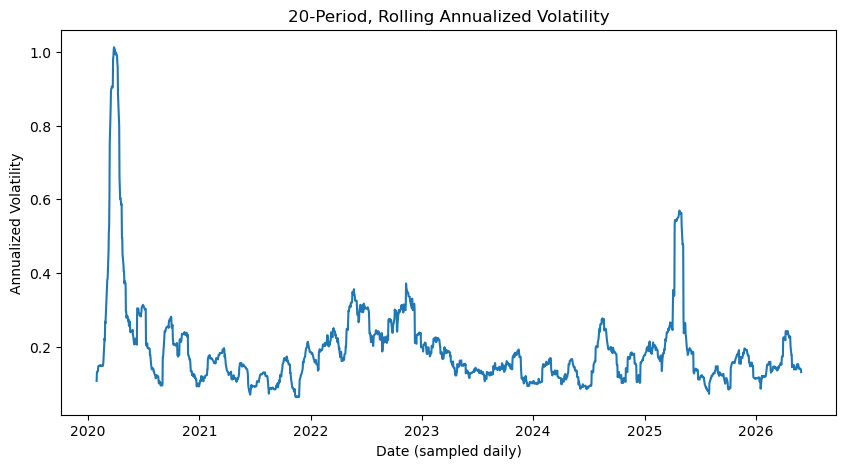

In [27]:
# Some tests
plot_cumulative_returns(ew_simple_daily_portfolio, return_type="simple_return", return_column="ew_portfolio_return", frequency="daily")
plot_rolling_volatility(ew_simple_daily_portfolio, frequency="daily", return_column="ew_portfolio_return", window=20)

plot_cumulative_returns(val_simple_daily_portfolio, return_type="simple_return", return_column="val_portfolio_return", frequency="daily")
plot_rolling_volatility(val_simple_daily_portfolio, frequency="daily", return_column="val_portfolio_return", window=20)